In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})

X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)
print(f'Train: {len(y_train)}, Test: {len(y_test)}')

Train: 210, Test: 90


### **(a)**

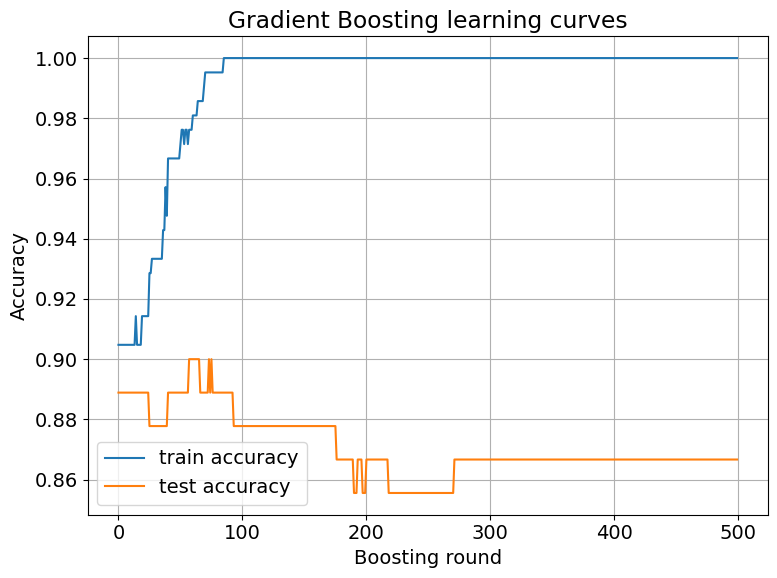

Best test accuracy: 0.90
Best round: 58


In [11]:
gb = GradientBoostingClassifier(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=0)
gb.fit(X_train, y_train)
gb_test_accs = []
gb_train_accs = []

for y_train_pred, y_test_pred in zip(gb.staged_predict(X_train), gb.staged_predict(X_test)):
    gb_train_accs.append(accuracy_score(y_train, y_train_pred))
    gb_test_accs.append(accuracy_score(y_test, y_test_pred))


plt.figure()
plt.plot(gb_train_accs, label="train accuracy")
plt.plot(gb_test_accs, label="test accuracy")
plt.xlabel("Boosting round")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting learning curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

best_round = np.argmax(gb_test_accs) + 1
best_test_acc = np.max(gb_test_accs)

print(f'Best test accuracy: {best_test_acc:.2f}')
print(f'Best round: {best_round}')

The test accuracy increases at small boosting round and eventually decrease. The turning point is at approximately 58 with a best test accuracy of 0.90.

### **(b)**

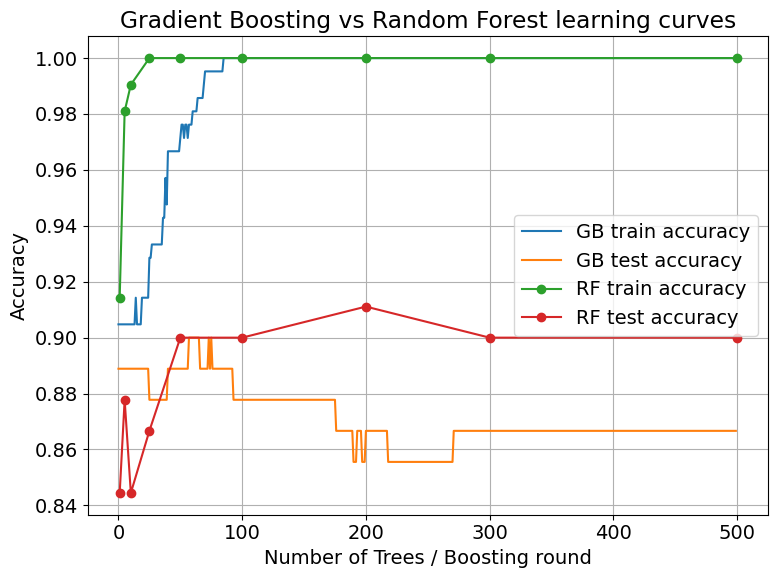

In [15]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300, 500]

rf_test_accs = []
rf_train_accs = []
for n_trees in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=None, max_features='sqrt', random_state=0)
    rf.fit(X_train, y_train)
    rf_train_accs.append(accuracy_score(y_train, rf.predict(X_train)))
    rf_test_accs.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure()
plt.plot(gb_train_accs, label="GB train accuracy")
plt.plot(gb_test_accs, label="GB test accuracy")
plt.plot(n_trees_list, rf_train_accs, "o-", label="RF train accuracy")
plt.plot(n_trees_list, rf_test_accs, "o-", label="RF test accuracy")
plt.xlabel("Number of Trees / Boosting round")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting vs Random Forest learning curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The random forest curve, though fluctuating, does not have an obvious decreasing trend. Gradient boosting adds trees to correct previous errors, so later trees can start fitting noise in the training set, which can reduce the test accuracy. In contrast, random forest trains trees independently. So adding trees simply reduce the variance and does not make the test accuracy decrease.

### **(c)**

Gradient boosting is analogous to neural network in the sense that each new tree is added in the direction that reduces the current loss, just as each neural network parameter update moves along the negative gradient of the loss. The "learning rate" is given by a shrinkage factor multiplying the tree in gradient boosting, and in neural network is the step size used in parameter updates. The boosting round plays the role of the "number of steps". In both methods, taking too many steps or using too large a rate can overfit the training data and start fitting noise. So test accuracy can eventually decrease in both.